# Week 3: A/B Testing and Retention Simulation
 
This phase takes churn-risk predictions, targets high-risk customers, simulates a retention strategy (treatment vs control), and evaluates whether the uplift is statistically significant.
 
## Goals
- Score customers with churn probability
- Select a high-risk segment
- Simulate an A/B retention campaign
- Measure retention lift
- Test significance with a two-proportion z-test
- Save outputs for reporting

In [2]:
# 1) Imports and setup
from pathlib import Path
 
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
 
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
 
RANDOM_SEED = 42
RISK_THRESHOLD = 0.70
UPLIFT = 0.08
ALPHA = 0.05

## Step 2: Load Week 2 Artifacts and Score Customers
Load the trained model from Week 2, score all customers, and create a probability column used to target high-risk users.

In [3]:
# 2) Load model and data, then score churn risk
project_root = Path.cwd().resolve()
candidate = project_root
for _ in range(8):
    if (candidate / "models" / "week2_best_model.joblib").exists() and (candidate / "data" / "cleaned_churn_data.csv").exists():
        project_root = candidate
        break
    if candidate.parent == candidate:
        break
    candidate = candidate.parent
 
model_path = project_root / "models" / "week2_best_model.joblib"
data_path = project_root / "data" / "cleaned_churn_data.csv"
 
if not model_path.exists():
    raise FileNotFoundError(f"Week 2 model not found at: {model_path}")
if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at: {data_path}")
 
model = joblib.load(model_path)
df = pd.read_csv(data_path)
 
label_col = "Churn" if "Churn" in df.columns else None
X_all = df.drop(columns=[label_col]) if label_col else df.copy()
 
if not hasattr(model, "predict_proba"):
    raise ValueError("Loaded model does not support predict_proba, required for risk scoring.")
 
df_scored = df.copy()
df_scored["churn_proba"] = model.predict_proba(X_all)[:, 1]
 
print(f"Using model: {model_path}")
print(f"Using data:  {data_path}")
print(f"Rows scored: {len(df_scored)}")
display(df_scored[["churn_proba"]].describe().T)

Using model: /Users/vrushil/Desktop/Temple University/Principle of Data Science/Predictive-Churn-Retention-Analysis-Data-Science-project/models/week2_best_model.joblib
Using data:  /Users/vrushil/Desktop/Temple University/Principle of Data Science/Predictive-Churn-Retention-Analysis-Data-Science-project/data/cleaned_churn_data.csv
Rows scored: 7043


,count,mean,std,min,25%,50%,75%,max
churn_proba,7043.0,0.390863,0.290539,0.003979,0.10338,0.354987,0.659,0.929242


## Step 3: Build High-Risk Segment and Run A/B Simulation
Customers above the risk threshold are split into control and treatment groups, then retention outcomes are simulated.

In [4]:
# 3) High-risk segment and A/B assignment
high_risk = df_scored[df_scored["churn_proba"] >= RISK_THRESHOLD].copy()
 
if high_risk.empty:
    # Fallback to top 30% risk if fixed threshold is too strict
    cutoff = df_scored["churn_proba"].quantile(0.70)
    high_risk = df_scored[df_scored["churn_proba"] >= cutoff].copy()
 
if high_risk.empty:
    raise ValueError("High-risk segment is empty after threshold and fallback.")
 
rng = np.random.default_rng(RANDOM_SEED)
high_risk["ab_group"] = rng.choice(["control", "treatment"], size=len(high_risk), p=[0.5, 0.5])
 
# Estimate baseline retention from churn label if available
base_retention = 0.35
if label_col:
    churn_num = high_risk[label_col].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0, "1": 1, "0": 0})
    if churn_num.notna().any():
        base_retention = float(np.clip(1 - churn_num.mean(), 0.05, 0.95))
 
high_risk["p_retention_sim"] = np.where(
    high_risk["ab_group"].eq("treatment"),
    np.clip(base_retention + UPLIFT, 0, 1),
    np.clip(base_retention, 0, 1),
)
high_risk["retained_sim"] = rng.binomial(1, high_risk["p_retention_sim"])
 
display(high_risk[["churn_proba", "ab_group", "p_retention_sim", "retained_sim"]].head())
print(f"High-risk customers: {len(high_risk)}")
print(f"Baseline retention used: {base_retention:.3f}")

,churn_proba,ab_group,p_retention_sim,retained_sim
0,0.725953,treatment,0.369439,1
4,0.848856,control,0.289439,0
5,0.900810,treatment,0.369439,0
8,0.752611,treatment,0.369439,1
19,0.722484,control,0.289439,0


High-risk customers: 1496
Baseline retention used: 0.289


## Step 4: Statistical Test and Business Summary
Use a two-proportion z-test to determine whether treatment significantly improved retention.

In [5]:
# 4) Two-proportion z-test and summary table
grp = high_risk.groupby("ab_group")["retained_sim"].agg(["sum", "count"])
for needed in ["control", "treatment"]:
    if needed not in grp.index:
        raise ValueError(f"Missing group '{needed}'. Try lowering threshold or using larger sample.")
 
x_t, n_t = int(grp.loc["treatment", "sum"]), int(grp.loc["treatment", "count"])
x_c, n_c = int(grp.loc["control", "sum"]), int(grp.loc["control", "count"])
p_t, p_c = x_t / n_t, x_c / n_c
lift = p_t - p_c
 
p_pool = (x_t + x_c) / (n_t + n_c)
se = np.sqrt(p_pool * (1 - p_pool) * (1 / n_t + 1 / n_c))
z_stat = (lift / se) if se > 0 else 0.0
p_value = 2 * (1 - norm.cdf(abs(z_stat)))
 
# 95% CI for absolute lift
se_diff = np.sqrt((p_t * (1 - p_t) / n_t) + (p_c * (1 - p_c) / n_c))
ci_low = lift - 1.96 * se_diff
ci_high = lift + 1.96 * se_diff
 
ab_results = pd.DataFrame(
    {
        "metric": [
            "high_risk_customers", "control_n", "treatment_n",
            "control_retention_rate", "treatment_retention_rate", "absolute_lift",
            "z_stat", "p_value", "significant_at_0.05", "ci95_low", "ci95_high"
        ],
        "value": [
            len(high_risk), n_c, n_t,
            round(p_c, 4), round(p_t, 4), round(lift, 4),
            round(float(z_stat), 4), round(float(p_value), 6), bool(p_value < ALPHA),
            round(float(ci_low), 4), round(float(ci_high), 4)
        ],
    }
)
 
display(ab_results)
 
if p_value < ALPHA:
    print("Result: Treatment effect is statistically significant at alpha=0.05.")
else:
    print("Result: Treatment effect is not statistically significant at alpha=0.05.")

,metric,value
0,high_risk_customers,1496
1,control_n,757
2,treatment_n,739
3,control_retention_rate,0.2867
4,treatment_retention_rate,0.3613
5,absolute_lift,0.0746
6,z_stat,3.0853
7,p_value,0.002033
8,significant_at_0.05,True
9,ci95_low,0.0273


Result: Treatment effect is statistically significant at alpha=0.05.


## Step 5: Visualization and Export
Plot retention rates and save Week 3 outputs for reporting and downstream analysis.

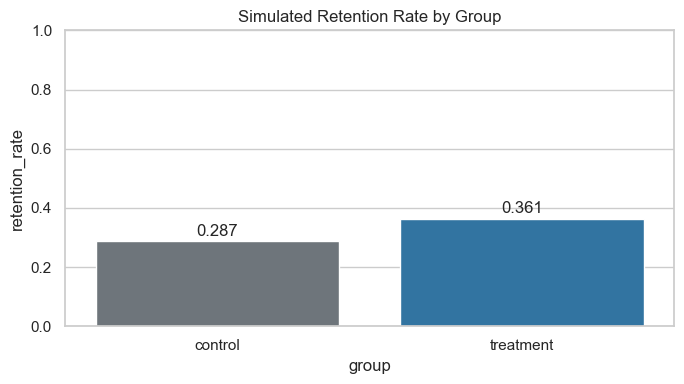

Saved summary: /Users/vrushil/Desktop/Temple University/Principle of Data Science/Predictive-Churn-Retention-Analysis-Data-Science-project/reports/week3_ab_test_summary.csv
Saved simulation details: /Users/vrushil/Desktop/Temple University/Principle of Data Science/Predictive-Churn-Retention-Analysis-Data-Science-project/reports/week3_high_risk_simulation.csv


In [7]:
# 5) Visualize and save outputs
rate_df = pd.DataFrame(
    {
        "group": ["control", "treatment"],
        "retention_rate": [p_c, p_t],
    }
)
 
plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=rate_df,
    x="group",
    y="retention_rate",
    hue="group",
    dodge=False,
    legend=False,
    palette={"control": "#6c757d", "treatment": "#1f77b4"},
)
ax.set_ylim(0, 1)
ax.set_title("Simulated Retention Rate by Group")
for i, v in enumerate(rate_df["retention_rate"]):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()
 
reports_dir = project_root / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)
 
ab_results_path = reports_dir / "week3_ab_test_summary.csv"
high_risk_path = reports_dir / "week3_high_risk_simulation.csv"
 
ab_results.to_csv(ab_results_path, index=False)
high_risk.to_csv(high_risk_path, index=False)
 
print(f"Saved summary: {ab_results_path}")
print(f"Saved simulation details: {high_risk_path}")